# SHAP Generation and Explanations

This notebook demonstrates how to generate SHAP explanations for compound selectivity models in this repository.

It includes:
- Optional end-to-end training (dataset -> features -> split -> model)
- SHAP generation from an existing split/model pair
- Atom-level SHAP visualizations on molecules
- SHAP explanations for custom SMILES strings

## Workflow Overview

1. Configure paths and model settings.
2. Either train a new model or reuse existing split/model artifacts.
3. Compute SHAP values for a selected split.
4. Render atom-level SHAP heatmaps for selected compounds.
5. Explain one custom SMILES and render its SHAP map.

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_workspace_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists() and (parent / "src").exists():
            return parent
    raise FileNotFoundError("Could not locate workspace root with pyproject.toml and src/")

workspace_root = find_workspace_root(Path.cwd())
src_path = workspace_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Workspace root: {workspace_root}")
print(f"Using src path:   {src_path}")

Workspace root: C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability
Using src path:   C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src


In [2]:
from chemagent.datasets.dataset_tools import (
    find_datasets,
    load_dataset,
    compute_features,
    split_dataset,
)
from chemagent.ml.training_tools import train_model, check_training

from chemagent.explainability.shap_explainer import (
    explain_with_shap,
    explain_smiles_with_shap,
    plot_shap_mol,
)

print("SHAP tools imported successfully.")

SHAP tools imported successfully.


## Interpretation Notes

- Large absolute SHAP values indicate fingerprint bits with strong influence on predictions.
- The SHAP molecule plots map bit-level contributions to atom-level heatmaps.
- For valid mapping, keep featurization consistent with training (`method`, `n_bits`, `radius`).
- For `explain_smiles_with_shap`, labels in output are model predictions, not ground truth.

In [3]:
path = 'C:/Users/janela/OneDrive - uni-bonn.de/Code/AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability/data/logs/session_tiago_20260416_103710_55bcdb'
model_path = Path(path) / "models" / "chembl_activity_RFC.pkl"
model = joblib.load(model_path)
dataset = pd.read_csv(Path(path) / "datasets" / "chembl_activity_data_P14416_binary.csv")
data_split_path = Path(path) / "splits" / "chembl_activity_data_P14416_binary_random.pkl"
data_split = joblib.load(data_split_path)


In [4]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
from chemagent.featurization.fingerprints import ECFP
ecfp_fp = np.array([ECFP(['CCCN(CCCCN1C(=O)CC(C)(C)CC1=O)C1CCc2ccc3[nH]c(C#N)cc3c2C1'])][0])
ecfp_fp

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 2048))

In [6]:
cpd_prediction = model.predict(ecfp_fp)
cpd_prediction

array([1])

In [7]:
from shap import TreeExplainer
explainer = TreeExplainer(model, feature_perturbation="interventional", data=data_split["train_features"])

In [8]:
cpd_explanation = explainer.shap_values(ecfp_fp)
cpd_explanation

array([[[ 0.00000000e+00,  0.00000000e+00],
        [-9.45056536e-04,  9.45056631e-04],
        [-1.46198526e-04,  1.46198525e-04],
        ...,
        [ 5.20041064e-04, -5.20041058e-04],
        [ 8.69746941e-05, -8.69746960e-05],
        [ 3.44444453e-05, -3.44444433e-05]]], shape=(1, 2048, 2))

In [9]:
from chemagent.explainability.shap_explainer import SHAPExplainer, explain_smiles_with_shap, plot_shap_mol

In [10]:
shap_ex = SHAPExplainer(model=model, background=data_split["train_features"])
shap_ex

In [11]:
explaination = shap_ex.explain(ecfp_fp)
explaination

array([[ 0.00000000e+00,  9.45056631e-04,  1.46198525e-04, ...,
        -5.20041058e-04, -8.69746960e-05, -3.44444433e-05]],
      shape=(1, 2048))

In [12]:
sum(explaination[0])

np.float64(0.17359999874955825)

In [13]:
explaination_with_smiles = explain_smiles_with_shap(model_path=model_path,  smiles=['CCCN(CCCCN1C(=O)CC(C)(C)CC1=O)C1CCc2ccc3[nH]c(C#N)cc3c2C1'], split_file_path=data_split_path)
explaination_with_smiles

{'split_file_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260416_103710_55bcdb\\splits\\chembl_activity_data_P14416_binary_random.pkl',
 'shap_values_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260420_121833_7bf32a\\results\\chembl_activity_RFC_smiles_shap.pkl',
 'n_samples': 1,
 'n_features': 2048,
 'expected_value': 0.44640000000000024,
 'expected_values_by_class': [0.5536000000000008, 0.44640000000000024],
 'expected_values_selected': [0.44640000000000024],
 'expected_value_classes': [0, 1],
 'expected_value_mode': 'class_1_or_single',
 'prediction': 1,
 'shap_sum': 0.17359999874955853,
 'method': 'ECFP',
 'has_smiles': True,
 'note': 'Labels in output file are model predictions, not ground truth.',
 'next_step': "Call plot_shap_mol('C:\\Users\\janela\\OneDrive - uni-bonn.de\

In [14]:
explaination_with_smiles.keys()

dict_keys(['split_file_path', 'shap_values_path', 'n_samples', 'n_features', 'expected_value', 'expected_values_by_class', 'expected_values_selected', 'expected_value_classes', 'expected_value_mode', 'prediction', 'shap_sum', 'method', 'has_smiles', 'note', 'next_step'])

In [15]:
mapping = plot_shap_mol(explaination_with_smiles["shap_values_path"])

mapping

[{'generated': ['C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260420_121833_7bf32a\\plots\\shap_mol_0_label1.png'],
  'molecules': {'0': {'path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260420_121833_7bf32a\\plots\\shap_mol_0_label1.png',
    'smiles': 'CCCN(CCCCN1C(=O)CC(C)(C)CC1=O)C1CCc2ccc3[nH]c(C#N)cc3c2C1',
    'label': '1',
    'cid': '0'}}},

In [16]:
mapping[1]

## Example: Top Positive and Negative SHAP Bits

This example shows how to retrieve the most important fingerprint bits for one explained sample, split into positive and negative contribution lists.

Run this after you have generated SHAP values (for example from `shap_ex.explain(...)` or `explain_smiles_with_shap(...)`).

Top 15 positive bits:


,bit,contribution
0,893,0.033694
1,231,0.030189
2,1326,0.028248
3,784,0.023838
4,1236,0.020884
5,1738,0.017131
6,1036,0.016663
7,353,0.012394
8,926,0.011678
9,1917,0.010507


Top 15 negative bits:


,bit,contribution
0,1480,-0.024852
1,1791,-0.020514
2,1274,-0.016921
3,1060,-0.014209
4,1482,-0.011566
5,1508,-0.009407
6,1199,-0.008503
7,314,-0.007239
8,1088,-0.006512
9,1057,-0.005908


Top bit environments and SHAP contributions:


,bit,contribution,environment_index,center_atom,radius,environment_smiles
0,893,0.033694,0,6,2,CCCCN
1,231,0.030189,0,32,1,cCC
2,1326,0.028248,0,3,1,CN(C)C
3,784,0.023838,0,8,2,CCN(C(=O)C)C(=O)C
4,1236,0.020884,0,21,1,cc(c)C
5,1738,0.017131,0,20,1,cCC
6,1274,-0.016921,0,13,1,CC
7,1036,0.016663,0,3,2,CCN(CC)C(C)C
8,1060,-0.014209,0,12,0,C
9,353,0.012394,0,9,2,CN(C)C(=O)CC


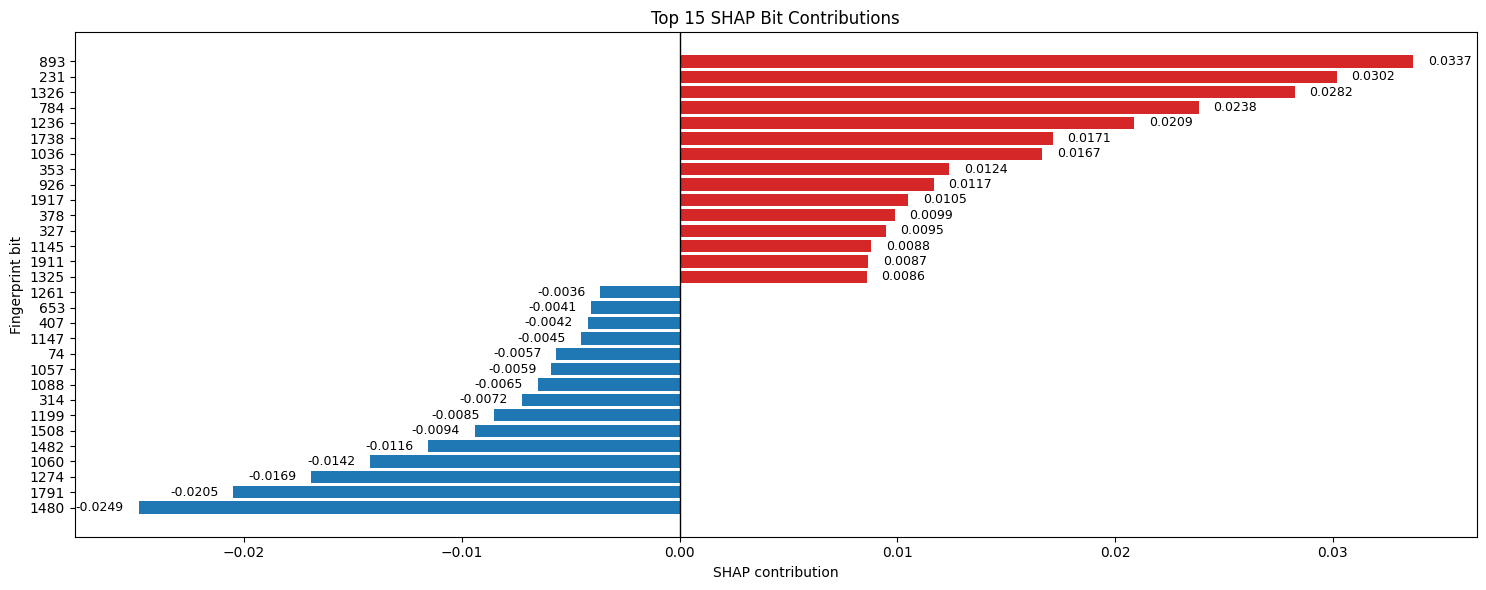

In [17]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chemagent.explainability.mol_shap_draw as mol_shap_draw

# Reload to ensure newly added helper functions are visible in long-lived kernels.
mol_shap_draw = importlib.reload(mol_shap_draw)

get_most_important_bits_by_contribution = mol_shap_draw.get_most_important_bits_by_contribution
get_top_k_bit_environments_with_contribution = mol_shap_draw.get_top_k_bit_environments_with_contribution
plot_bit_contribution_summary = mol_shap_draw.plot_bit_contribution_summary

# 1) Pick a SHAP vector from variables created in previous cells.
if "explaination" in globals():
    shap_vector = np.asarray(explaination[0])
elif "cpd_explanation" in globals():
    raw = cpd_explanation
    if isinstance(raw, list):
        shap_vector = np.asarray(raw[1][0] if len(raw) > 1 else raw[0][0])
    else:
        arr = np.asarray(raw)
        shap_vector = arr[0] if arr.ndim == 2 else arr[0, :, -1]
else:
    raise RuntimeError("Run a SHAP generation cell first so SHAP values exist in memory.")

# 2) Retrieve top positive and negative bits.
top_k = 15
bit_summary = get_most_important_bits_by_contribution(shap_vector, top_k=top_k)

# 3) Display tables.
positive_bits = pd.DataFrame(bit_summary["positive"])
negative_bits = pd.DataFrame(bit_summary["negative"])
print(f"Top {top_k} positive bits:")
display(positive_bits)
print(f"Top {top_k} negative bits:")
display(negative_bits)

# 4) Display top-k bit environments with SHAP contribution.
if "ecfp_fp" not in globals():
    raise RuntimeError("Run the ECFP feature cell first so a molecule example exists.")
if "model" not in globals():
    raise RuntimeError("Run the model loading cell first.")

example_smiles = "CCCN(CCCCN1C(=O)CC(C)(C)CC1=O)C1CCc2ccc3[nH]c(C#N)cc3c2C1"
mol = mol_shap_draw.Chem.MolFromSmiles(example_smiles)
bit_info = mol_shap_draw.get_ecfp_morgan_generator_bit_info(example_smiles, radius=2, n_bits=shap_vector.shape[0])
top_env = get_top_k_bit_environments_with_contribution(
    mol,
    bit_info,
    shap_vector,
    top_k=top_k,
    ranking="absolute",
)

env_rows = []
for item in top_env:
    for i, env in enumerate(item["environments"]):
        env_rows.append(
            {
                "bit": item["bit"],
                "contribution": item["contribution"],
                "environment_index": i,
                "center_atom": env["center_atom"],
                "radius": env["radius"],
                "environment_smiles": env["environment_smiles"],
            }
        )

env_df = pd.DataFrame(env_rows)
print("Top bit environments and SHAP contributions:")
display(env_df)

# 5) Plot contribution summary.
ax = plot_bit_contribution_summary(bit_summary, title=f"Top {top_k} SHAP Bit Contributions")
display(ax.figure)
plt.close(ax.figure)

In [18]:
env_df

,bit,contribution,environment_index,center_atom,radius,environment_smiles
0,893,0.033694,0,6,2,CCCCN
1,231,0.030189,0,32,1,cCC
2,1326,0.028248,0,3,1,CN(C)C
3,784,0.023838,0,8,2,CCN(C(=O)C)C(=O)C
4,1236,0.020884,0,21,1,cc(c)C
5,1738,0.017131,0,20,1,cCC
6,1274,-0.016921,0,13,1,CC
7,1036,0.016663,0,3,2,CCN(CC)C(C)C
8,1060,-0.014209,0,12,0,C
9,353,0.012394,0,9,2,CN(C)C(=O)CC


In [19]:
bit_info[353]

((9, 2), (16, 2))

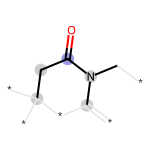

In [20]:
from rdkit.Chem import Draw

Draw.DrawMorganBit(mol, 353, bit_info)

Top positive fragment environments:


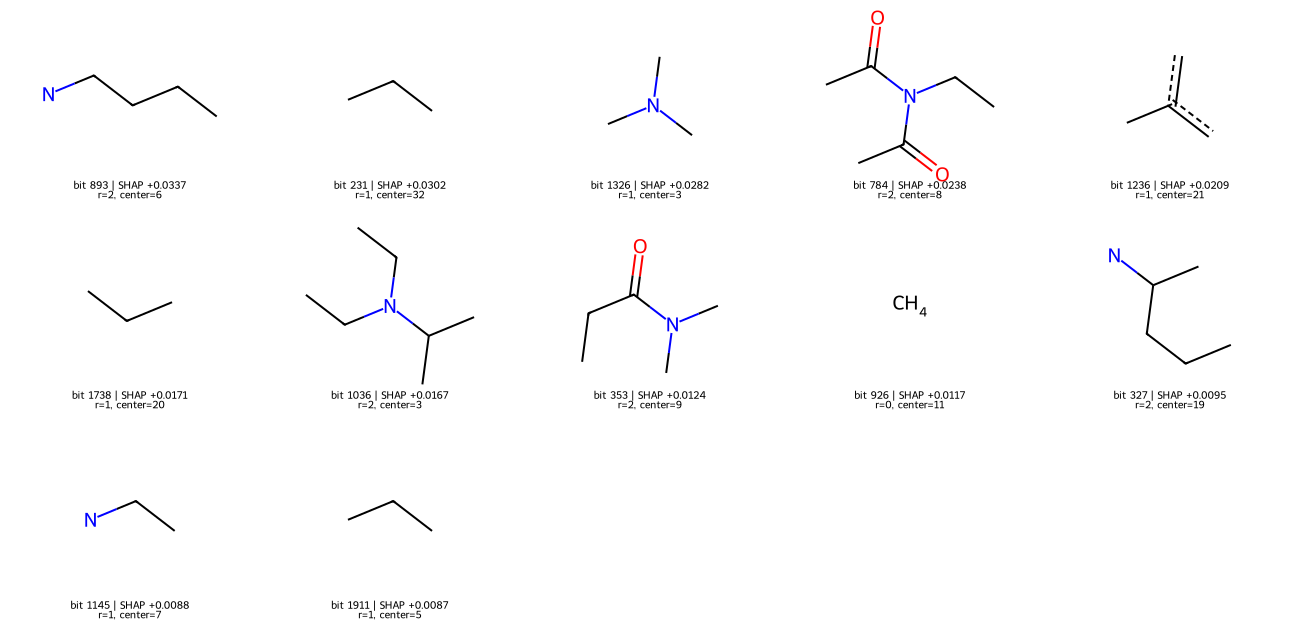

Top negative fragment environments:


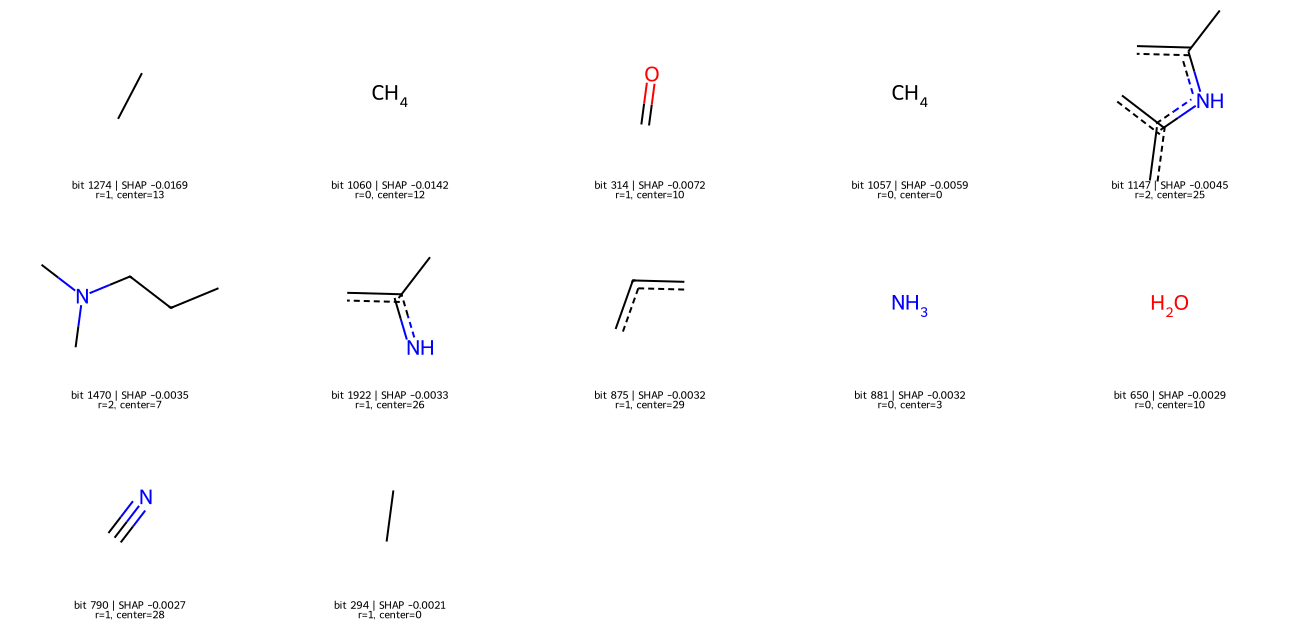

Parent-molecule highlights for top environments:


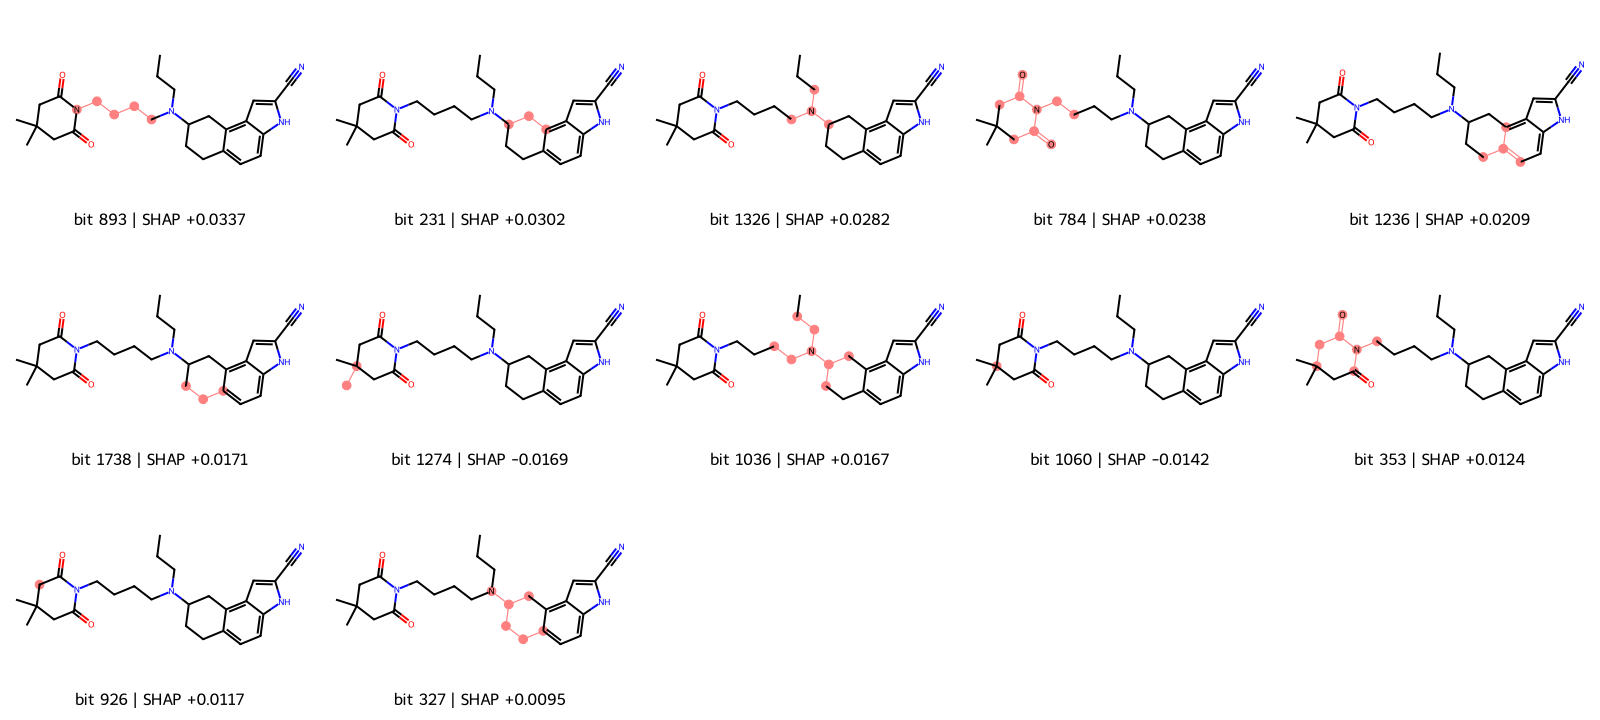

Combined top-k feature map on one parent molecule:


In [21]:
# 6) Render top environments as molecule images.

render_top_positive_negative_bit_environments_images = (
    mol_shap_draw.render_top_positive_negative_bit_environments_images
)
render_top_k_parent_molecule_environment_highlights = (
    mol_shap_draw.render_top_k_parent_molecule_environment_highlights
)
map_top_k_features_to_parent_molecule = (
    mol_shap_draw.map_top_k_features_to_parent_molecule
)

env_images_by_sign = render_top_positive_negative_bit_environments_images(
    mol,
    bit_info,
    shap_vector,
    top_k=top_k,
    max_environments_per_sign=12,
    mols_per_row=5,
    sub_img_size=(260, 210),
)

print("Top positive fragment environments:")
if env_images_by_sign["positive"] is not None:
    display(env_images_by_sign["positive"])
else:
    print("No positive SHAP environments found.")

print("Top negative fragment environments:")
if env_images_by_sign["negative"] is not None:
    display(env_images_by_sign["negative"])
else:
    print("No negative SHAP environments found.")

print("Parent-molecule highlights for top environments:")
parent_env_image = render_top_k_parent_molecule_environment_highlights(
    mol,
    bit_info,
    shap_vector,
    top_k=top_k,
    ranking="absolute",
    max_environments=12,
    mols_per_row=5,
    sub_img_size=(320, 240),
)

display(parent_env_image)

print("Combined top-k feature map on one parent molecule:")
combined_mapping = map_top_k_features_to_parent_molecule(
    mol,
    bit_info,
    shap_vector,
    top_k=top_k,
    ranking="absolute",
)